
# Queue Reactive simple model — Questions 1.2.3

In [20]:

import math
import numpy as np
import matplotlib.pyplot as plt
from statistics import NormalDist

rng = np.random.default_rng(42)


In [21]:

# Paramètres de base
lambda_add = 1.2   
lambda_dec = 1.5  
q_ask0 = 10
q_bid0 = 10

# Paramètres de l'approximation brownienne
mu = lambda_add - lambda_dec
sigma2 = lambda_add + lambda_dec
sigma = math.sqrt(sigma2)

print(f"Drift brownien μ = {mu:.3f}")
print(f"Variance brownienne σ² = {sigma2:.3f}")
print(f"Écart-type brownien σ = {sigma:.3f}")


Drift brownien μ = -0.300
Variance brownienne σ² = 2.700
Écart-type brownien σ = 1.643



## 1. Simulation exacte de deux files indépendantes

Dynamique à temps continu de chaque file :
- attente exponentielle de paramètre `lambda_add + lambda_dec`,
- puis saut de `+1` avec probabilité `lambda_add / (lambda_add + lambda_dec)`,
- ou saut de `-1` avec probabilité `lambda_dec / (lambda_add + lambda_dec)`.

On s'arrête au **premier instant où une file touche zéro**


In [ ]:

def simulate_one_queue_until_zero(q0, lambda_add, lambda_dec, rng=None, max_events=100000):
    """Simule une file unique jusqu'à son premier temps d'atteinte de zéro."""
    if rng is None:
        rng = np.random.default_rng()
    if q0 <= 0:
        return {
            "times": np.array([0.0]),
            "states": np.array([q0], dtype=int),
            "tau": 0.0,
            "n_events": 0,
        }

    rate = lambda_add + lambda_dec
    p_up = lambda_add / rate

    t = 0.0
    q = int(q0)
    times = [t]
    states = [q]

    for _ in range(max_events):
        t += rng.exponential(1.0 / rate)
        step = 1 if rng.random() < p_up else -1
        q += step
        times.append(t)
        states.append(q)
        if q <= 0:
            break
    else:
        raise RuntimeError("max_events reached before hitting zero")

    return {
        "times": np.array(times),
        "states": np.array(states, dtype=int),
        "tau": t,
        "n_events": len(states) - 1,
    }


def simulate_two_queues_until_first_hit(q_ask0, q_bid0, lambda_add, lambda_dec, rng=None, max_events=4_000_000):
    """Simule deux files indépendantes jusqu'au premier temps où l'une touche zéro."""
    if rng is None:
        rng = np.random.default_rng()

    if q_ask0 <= 0 or q_bid0 <= 0:
        first = "ask" if q_ask0 <= 0 else "bid"
        return {
            "times": np.array([0.0]),
            "ask": np.array([q_ask0], dtype=int),
            "bid": np.array([q_bid0], dtype=int),
            "tau_first": 0.0,
            "first_queue": first,
        }

    rate_total = 2.0 * (lambda_add + lambda_dec)
    p_ask = 0.5
    p_up = lambda_add / (lambda_add + lambda_dec)

    t = 0.0
    qa, qb = int(q_ask0), int(q_bid0)
    times = [t]
    ask_path = [qa]
    bid_path = [qb]

    for _ in range(max_events):
        t += rng.exponential(1.0 / rate_total)
        is_ask = rng.random() < p_ask
        step = 1 if rng.random() < p_up else -1

        if is_ask:
            qa += step
        else:
            qb += step

        times.append(t)
        ask_path.append(qa)
        bid_path.append(qb)

        if qa <= 0 or qb <= 0:
            first = "ask" if qa <= 0 else "bid"
            return {
                "times": np.array(times),
                "ask": np.array(ask_path, dtype=int),
                "bid": np.array(bid_path, dtype=int),
                "tau_first": t,
                "first_queue": first,
            }

    raise RuntimeError("max_events reached before first hit")


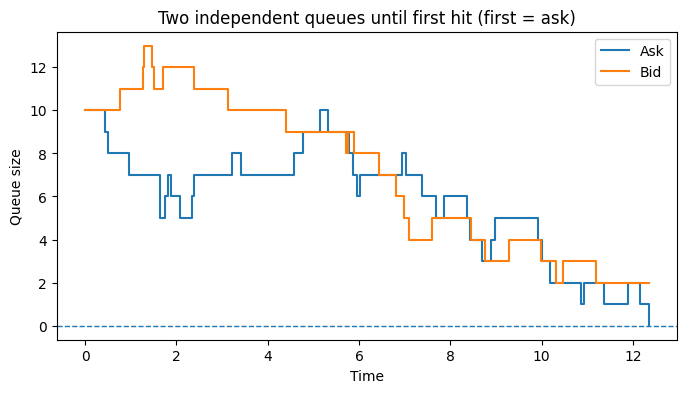

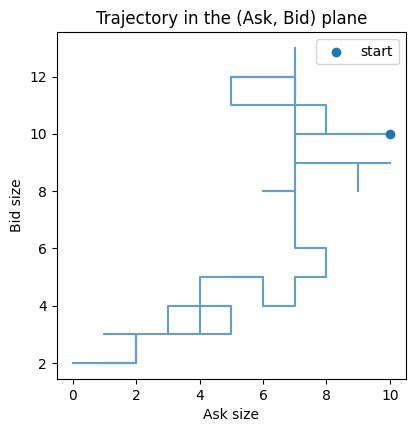

In [23]:

# Exemple d'une trajectoire 2D
sample = simulate_two_queues_until_first_hit(q_ask0, q_bid0, lambda_add, lambda_dec, rng=rng)

plt.figure(figsize=(8, 4))
plt.step(sample["times"], sample["ask"], where="post", label="Ask")
plt.step(sample["times"], sample["bid"], where="post", label="Bid")
plt.axhline(0, linestyle="--", linewidth=1)
plt.xlabel("Time")
plt.ylabel("Queue size")
plt.title(f"Two independent queues until first hit (first = {sample['first_queue']})")
plt.legend()
plt.show()

plt.figure(figsize=(4.5, 4.5))
plt.plot(sample["ask"], sample["bid"], alpha=0.7)
plt.scatter([q_ask0], [q_bid0], label="start")
plt.xlabel("Ask size")
plt.ylabel("Bid size")
plt.title("Trajectory in the (Ask, Bid) plane")
plt.legend()
plt.show()



## 2. Approximation brownienne et temps d'atteinte

Pour une file seule, on approxime
$$
Q(t) \approx q_0 + \mu t + \sigma W_t,
\qquad
\mu = \lambda_{add} - \lambda_{dec},
\qquad
\sigma^2 = \lambda_{add} + \lambda_{dec}.
$$

Quand `mu < 0`, le temps d'atteinte de zéro de ce brownien a une loi d'**Inverse Gaussian** de densité
$$
 f_{\tau}(t)
 = \frac{q_0}{\sigma\sqrt{2\pi t^3}}
 \exp\!\left(-\frac{(q_0 + \mu t)^2}{2\sigma^2 t}\right), \qquad t>0.
$$


In [24]:

def brownian_hitting_time_theory_pdf(t, q0, mu, sigma):
    t = np.asarray(t, dtype=float)
    out = np.zeros_like(t)
    mask = t > 0
    tm = t[mask]
    out[mask] = (q0 / (sigma * np.sqrt(2.0 * np.pi * tm**3))) * np.exp(-((q0 + mu * tm) ** 2) / (2.0 * sigma**2 * tm))
    return out


def simulate_brownian_until_zero(q0, mu, sigma, dt=0.01, rng=None, t_max=10_000.0):
    """Simulation Euler d'un mouvement brownien arithmétique jusqu'à 0."""
    if rng is None:
        rng = np.random.default_rng()
    if q0 <= 0:
        return 0.0

    x = float(q0)
    t = 0.0
    sqrt_dt = math.sqrt(dt)

    while x > 0 and t < t_max:
        x += mu * dt + sigma * sqrt_dt * rng.normal()
        t += dt
    return t


def sample_poisson_hitting_times(n_samples, q0, lambda_add, lambda_dec, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    return np.array([
        simulate_one_queue_until_zero(q0, lambda_add, lambda_dec, rng=rng)["tau"]
        for _ in range(n_samples)
    ])


def sample_brownian_hitting_times(n_samples, q0, mu, sigma, dt=0.01, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    return np.array([
        simulate_brownian_until_zero(q0, mu, sigma, dt=dt, rng=rng)
        for _ in range(n_samples)
    ])


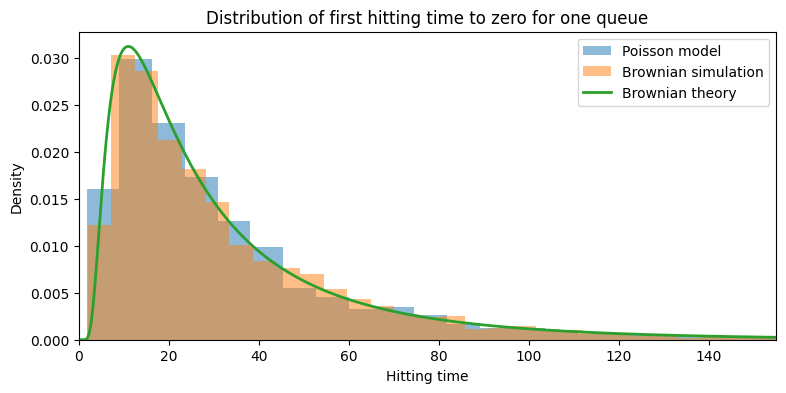

In [25]:

# Comparaison des distributions de temps d'atteinte pour une file seule
n_samples = 4000
q0 = q_ask0

poisson_tau = sample_poisson_hitting_times(n_samples, q0, lambda_add, lambda_dec, rng=rng)
brown_tau = sample_brownian_hitting_times(n_samples, q0, mu, sigma, dt=0.01, rng=rng)

upper = np.quantile(np.concatenate([poisson_tau, brown_tau]), 0.99)
grid = np.linspace(1e-3, upper, 400)
pdf_theory = brownian_hitting_time_theory_pdf(grid, q0, mu, sigma)

plt.figure(figsize=(9, 4))
plt.hist(poisson_tau, bins=60, density=True, alpha=0.5, label="Poisson model")
plt.hist(brown_tau, bins=60, density=True, alpha=0.5, label="Brownian simulation")
plt.plot(grid, pdf_theory, linewidth=2, label="Brownian theory")
plt.xlim(0, upper)
plt.xlabel("Hitting time")
plt.ylabel("Density")
plt.title("Distribution of first hitting time to zero for one queue")
plt.legend()
plt.show()



## 3. Temps moyen d'atteinte et intervalle de confiance

On estime ici le temps moyen d'atteinte de zéro pour **une file** puis pour le **premier temps d'atteinte parmi les deux files**, avec un intervalle de confiance asymptotique à 95% :
$$
\bar\tau \pm 1.96 \frac{s}{\sqrt{n}}.
$$


In [26]:

def mean_confidence_interval(x, level=0.95):
    x = np.asarray(x, dtype=float)
    n = len(x)
    mean = x.mean()
    s = x.std(ddof=1)
    z = NormalDist().inv_cdf(0.5 + level / 2.0)
    half_width = z * s / math.sqrt(n)
    return mean, mean - half_width, mean + half_width

# Une file
mean_one, ci1_low, ci1_high = mean_confidence_interval(poisson_tau)
print("One queue hitting time")
print(f"Mean = {mean_one:.4f}")
print(f"95% CI = [{ci1_low:.4f}, {ci1_high:.4f}]")

# Deux files : premier temps d'atteinte de zéro
n_samples_two = 4000
first_hit_tau = np.array([
    simulate_two_queues_until_first_hit(q_ask0, q_bid0, lambda_add, lambda_dec, rng=rng)["tau_first"]
    for _ in range(n_samples_two)
])
mean_two, ci2_low, ci2_high = mean_confidence_interval(first_hit_tau)
print("First hitting time among the two queues")
print(f"Mean = {mean_two:.4f}")
print(f"95% CI = [{ci2_low:.4f}, {ci2_high:.4f}]")


One queue hitting time
Mean = 33.0127
95% CI = [32.0302, 33.9952]
First hitting time among the two queues
Mean = 18.6232
95% CI = [18.1953, 19.0511]



## 4. Temps moyen du premier temps d'atteinte en fonction des conditions initiales

Le point 4 demande d'étudier la moyenne de
$$
\tau = \tau_{ask} \wedge \tau_{bid}
$$

selon `Q_ask(0)` et `Q_bid(0)`. On fixe ci-dessous une petite grille de valeurs initiales et on calcule la moyenne empirique. fileciteturn1file0


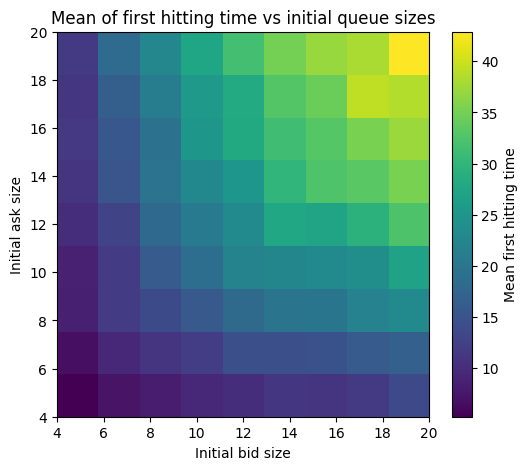

In [27]:

def estimate_mean_first_hit(q_ask0, q_bid0, lambda_add, lambda_dec, n_samples=1000, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    vals = [
        simulate_two_queues_until_first_hit(q_ask0, q_bid0, lambda_add, lambda_dec, rng=rng)["tau_first"]
        for _ in range(n_samples)
    ]
    return float(np.mean(vals))

q_values = np.arange(4, 21, 2)
mean_grid = np.zeros((len(q_values), len(q_values)))

for i, qa0 in enumerate(q_values):
    for j, qb0 in enumerate(q_values):
        mean_grid[i, j] = estimate_mean_first_hit(qa0, qb0, lambda_add, lambda_dec, n_samples=400, rng=rng)

plt.figure(figsize=(6, 5))
plt.imshow(mean_grid, origin="lower", aspect="auto",
           extent=[q_values[0], q_values[-1], q_values[0], q_values[-1]])
plt.colorbar(label="Mean first hitting time")
plt.xlabel("Initial bid size")
plt.ylabel("Initial ask size")
plt.title("Mean of first hitting time vs initial queue sizes")
plt.show()



## 5. Probabilité que la file ask touche zéro avant la file bid

On estime:
$$
\mathbb{P}(\tau_{ask} < \tau_{bid})
$$

en fonction des tailles initiales. Quand `Q_ask(0)` est petite relativement à `Q_bid(0)`, cette probabilité doit naturellement être plus grande.


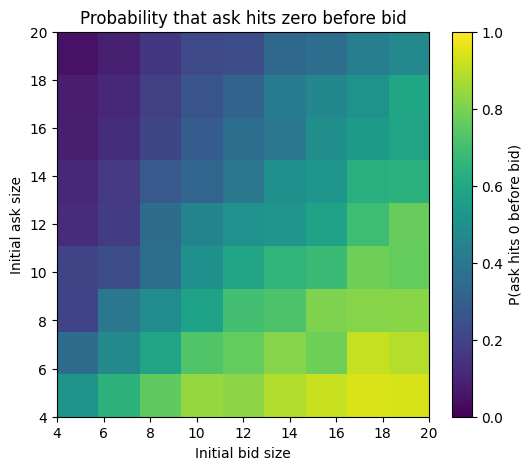

In [ ]:

def estimate_prob_ask_hits_first(q_ask0, q_bid0, lambda_add, lambda_dec, n_samples=1000, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    hits = 0
    for _ in range(n_samples):
        out = simulate_two_queues_until_first_hit(q_ask0, q_bid0, lambda_add, lambda_dec, rng=rng)
        hits += (out["first_queue"] == "ask")
    return hits / n_samples

prob_grid = np.zeros((len(q_values), len(q_values)))
for i, qa0 in enumerate(q_values):
    for j, qb0 in enumerate(q_values):
        prob_grid[i, j] = estimate_prob_ask_hits_first(qa0, qb0, lambda_add, lambda_dec, n_samples=400, rng=rng)

plt.figure(figsize=(6, 5))
plt.imshow(prob_grid, origin="lower", aspect="auto", vmin=0, vmax=1,
           extent=[q_values[0], q_values[-1], q_values[0], q_values[-1]])
plt.colorbar(label="P(ask hits 0 before bid)")
plt.xlabel("Initial bid size")
plt.ylabel("Initial ask size")
plt.title("Probability that ask hits zero before bid")
plt.show()

